# Data Normalization

In [30]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, QuantileTransformer


In [31]:
# make a ranodm non mormal data
data= np.random.exponential(scale=2, size=1000)
data= pd.DataFrame(data, columns=["values"])
data.head()

,values
0,1.793342
1,1.533676
2,0.693791
3,0.039043
4,3.837154


<Axes: xlabel='values', ylabel='Count'>

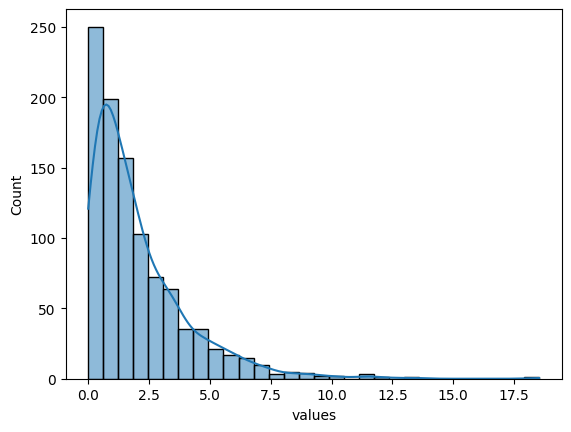

In [32]:
# make a histplot of this data
sns.histplot(data=data, x='values', bins=30, kde=True)

In [33]:
# Box-Cox and Yeo-Johnson transformations
pt_box_cox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_johnson = PowerTransformer(method='yeo-johnson', standardize=False)
df = data.copy()

# boxcox ky lye +1 add krna lazmi hai
df['Box_Cox'] = pt_box_cox.fit_transform(df[['values']] + 1)
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['values']])

df.head(10)

,values,Box_Cox,Yeo_Johnson
0,1.793342,0.857673,0.857673
1,1.533676,0.789235,0.789235
2,0.693791,0.479697,0.479697
3,0.039043,0.038036,0.038036
4,3.837154,1.200779,1.200779
5,0.488199,0.370248,0.370248
6,7.026509,1.462062,1.462062
7,2.149067,0.938506,0.938506
8,1.479772,0.773823,0.773823
9,1.568665,0.799002,0.799002


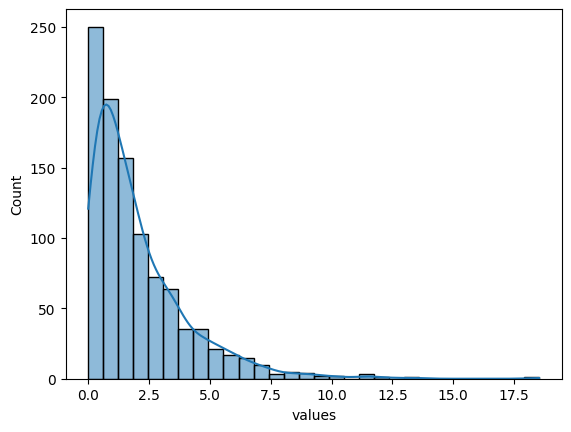

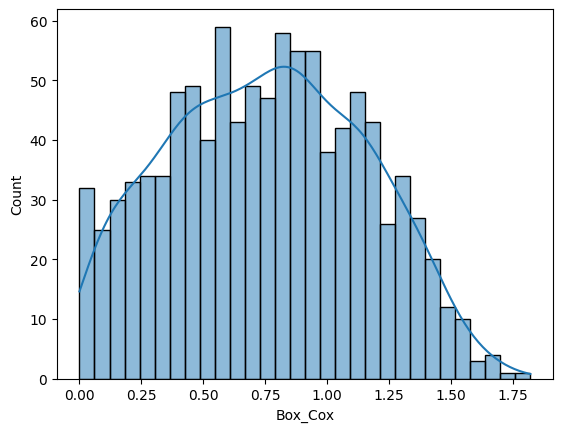

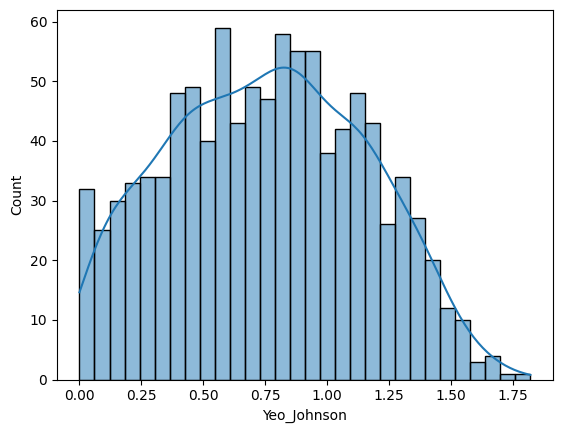

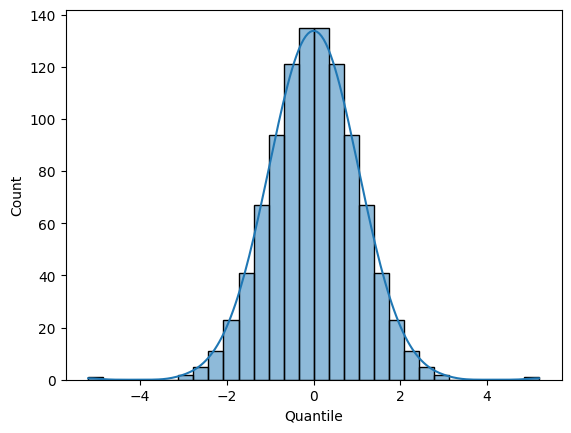

In [39]:
# now make a histogram of the transformed data
for col in ['values', 'Box_Cox', 'Yeo_Johnson', 'Quantile']:
    sns.histplot(data=df, bins=30, x=col, kde=True)
    plt.show()